In [ ]:
import pandas as pd
import numpy as np
import random as rd
import matplotlib.pyplot as plt
import math

: 

# Data creation

In [4]:
K=3
center_1 = np.array([3,2])
center_2 = np.array([1,5])
center_3 = np.array([8,1])

clusters = []
# Generate random data and center it to the three centers
cluster_1 = np.random.randn(100, 2) + center_1
cluster_2 = np.random.randn(100,2) + center_2
cluster_3 = np.random.randn(100,2) + center_3

clusters.append(cluster_1)
clusters.append(cluster_2)
clusters.append(cluster_3)




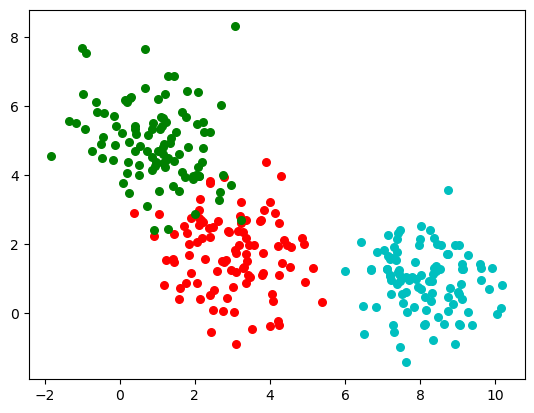

In [5]:
# visualize the data
colors = ["r", "g", "c", "b", "k"]
for cluster_index in range(K):
    color = colors[cluster_index]
    for features in clusters[cluster_index]:
        plt.scatter(features[0], features[1], color = color,s = 30)

In [6]:
data = np.concatenate((cluster_1, cluster_2, cluster_3), axis = 0)
np.random.shuffle(data)  

# K_means implementation

In [2]:
class K_Means:
    
    def __init__(self, num_cluster=2, distance_tolerance = 0.001, maximum_iteration = 500):
        self.k = num_cluster
        self.max_iterations = maximum_iteration
        self.tolerance = distance_tolerance
        self.centroids = {}
        self.classes = {}
    
    def calculate_euclidean_distance(self, point1, point2):
        return math.sqrt((point1[0]-point2[0])**2 + (point1[1]-point2[1])**2)   #sqrt((x1-x2)^2 + (y1-y2)^2)
        #return np.linalg.norm(point1-point2, axis=0)
        
    
        
    def predict(self, data):
        distances = []
        for i in self.centroids:
            distances.append(self.calculate_euclidean_distance(data, self.centroids[i]))
            cluster_index = int(np.argmin(distances))
        return cluster_index
    
    def train(self, data):
        self.centroids = {} #initialize to empty
        for i in range(self.k): # assign first few points as starting centroid
            self.centroids[i] = data[i]
        
        #iterate and update
        for i in range(self.max_iterations):
            # dict to store cluster.
            # For example, self.class[1] will store all the pts belonging to cluster1. 
            # Initializing them to be empty
            self.classes = {} 
            for j in range(self.k):
                self.classes[j] = []
                
            for point in data:
                distances = []
                for c in self.centroids:
                    distances.append(self.calculate_euclidean_distance(point, self.centroids[c]))
                    classification = int(np.argmin(distances))
                    self.classes[classification].append(point)
            
            
            #update the centroids
            previous = dict(self.centroids)# keep note of the previous cluster centroids
            for cluster_index in self.classes:
                 self.centroids[cluster_index] = np.average(self.classes[cluster_index], axis=0)
                #TODO:
                #iterate over each class and recalculate the centroid 
               
            

            # check for stopping criteria.
            # if for any cluster the difference between curr centroid and
            # the previous centroid is greater than tolerance keep going.
            # Otherwise stop
            isOptimal = True
            
            for centroid in self.centroids:
                original_centroid = previous[centroid]
                curr = self.centroids[centroid]
                if np.sum((curr - original_centroid)/original_centroid * 100.0) > self.tolerance:
                    isOptimal = False
            if isOptimal:
                break

In [7]:
k_means = K_Means(num_cluster=K)
k_means.train(data)
     

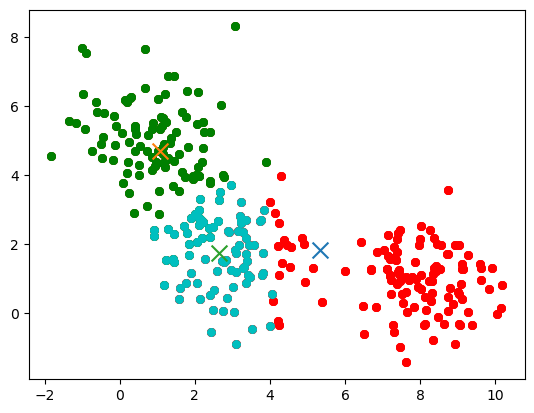

In [8]:
# Plotting the clusters
colors = ["r", "g", "c", "b", "k"]

for cluster_index in k_means.classes:
    color = colors[cluster_index]
    for features in k_means.classes[cluster_index]:
        plt.scatter(features[0], features[1], color = color,s = 30)
for centroid in k_means.centroids:
    plt.scatter(k_means.centroids[centroid][0], k_means.centroids[centroid][1], s = 130, marker = "x")